# Loading data (electric power consumption  - https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('powerconsumption.csv', parse_dates=['Datetime'])
df.set_index('Datetime', inplace=True)
# hourly aggregation in order to catch weekly trends
df_hourly = df.resample('h').mean()

print(df_hourly.columns)
print(np.sum(df_hourly.isnull()))
df_hourly.describe()

Index(['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows',
       'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2',
       'PowerConsumption_Zone3'],
      dtype='str')
0


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
count,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.807624,15.475739,2.340551,260.820277,119.691920,7068.919876,5165.178202,6591.013989
min,3.602167,12.710000,0.054667,0.019000,0.040000,14329.113923,8685.947047,6190.636254
25%,14.403750,58.324583,0.078167,0.064000,0.124167,26292.951730,17016.901716,13148.470246
50%,18.759167,69.815833,0.085500,9.947417,8.241250,32342.303347,20787.229493,16427.659642
75%,22.866667,81.350000,4.915333,326.487500,105.883333,37318.002218,24677.609019,21598.447824
max,39.695000,94.750000,5.933667,953.350000,861.000000,51844.261932,36254.699050,47223.765690


# Feature engineering

In [2]:
df_hourly['hour'] = df_hourly.index.hour
df_hourly['dayofweek'] = df_hourly.index.dayofweek

features = ['Temperature', 'Humidity', 'WindSpeed', 'hour', 'dayofweek', 'PowerConsumption_Zone1']

data_filtered = df_hourly[features].copy()

target_idx = features.index('PowerConsumption_Zone1')

data_filtered.describe()

,Temperature,Humidity,WindSpeed,hour,dayofweek,PowerConsumption_Zone1
count,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000,8736.000000
mean,18.810024,68.259518,1.959489,11.500000,3.000000,32344.970564
std,5.807624,15.475739,2.340551,6.922583,2.000114,7068.919876
min,3.602167,12.710000,0.054667,0.000000,0.000000,14329.113923
25%,14.403750,58.324583,0.078167,5.750000,1.000000,26292.951730
50%,18.759167,69.815833,0.085500,11.500000,3.000000,32342.303347
75%,22.866667,81.350000,4.915333,17.250000,5.000000,37318.002218
max,39.695000,94.750000,5.933667,23.000000,6.000000,51844.261932


# 4.1

## LSTM

In [3]:
from torch.utils.data import Dataset, DataLoader

class MultivariateSeqDataset(Dataset):
    def __init__(self, data, seq_len, horizon, target_idx=0, seq2seq=False):
        self.data = torch.FloatTensor(data)
        self.seq_len = seq_len
        self.horizon = horizon
        self.tidx = target_idx
        self.seq2seq = seq2seq
        
    def __len__(self):
        return len(self.data) - self.seq_len - self.horizon + 1
        
    def __getitem__(self, i):
        x = self.data[i : i + self.seq_len]
        if self.seq2seq:
            # Seq2Seq - predict whole sequence of length horizon
            y = self.data[i + self.seq_len : i + self.seq_len + self.horizon, self.tidx]
        else:
            # Seq2One - predict only one datapoint
            y = self.data[i + self.seq_len + self.horizon - 1, self.tidx]
        return x, y

class LSTMSeq2One(nn.Module):
    def __init__(self, input_size=4, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers, dropout=dropout if layers>1 else 0, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(h[-1]).squeeze(-1)


class LSTMSeq2Seq(nn.Module):
    def __init__(self, input_size=4, hidden=64, layers=2, horizon=24, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers, dropout=dropout if layers>1 else 0, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, horizon)
        )
        
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(h[-1])

In [4]:
import torch.optim as optim
from sklearn.metrics import mean_squared_error, mean_absolute_error

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Active device: {device}")

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def train_lstm(model, train_loader, test_loader, epochs=15, lr=0.001):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                val_loss += criterion(out, yb).item() * xb.size(0)
        val_loss = val_loss / len(test_loader.dataset)
        val_losses.append(val_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            
    return model, train_losses, val_losses

Active device: cpu


## Seq2seq

Training: LSTM_seq=12
Epoch 5/15 | Train Loss: 0.2263 | Val Loss: 0.6697
Epoch 10/15 | Train Loss: 0.2348 | Val Loss: 0.6458
Epoch 15/15 | Train Loss: 0.2346 | Val Loss: 0.6210
Training: LSTM_seq=24
Epoch 5/15 | Train Loss: 0.2024 | Val Loss: 0.6533
Epoch 10/15 | Train Loss: 0.2254 | Val Loss: 0.5613
Epoch 15/15 | Train Loss: 0.2195 | Val Loss: 0.5343
Training: LSTM_seq=36
Epoch 5/15 | Train Loss: 0.2073 | Val Loss: 0.6281
Epoch 10/15 | Train Loss: 0.2246 | Val Loss: 0.5863
Epoch 15/15 | Train Loss: 0.2214 | Val Loss: 0.5648
Training: LSTM_seq=48
Epoch 5/15 | Train Loss: 0.2139 | Val Loss: 0.6458
Epoch 10/15 | Train Loss: 0.2187 | Val Loss: 0.5930
Epoch 15/15 | Train Loss: 0.2239 | Val Loss: 0.5466
Training: LSTM_seq=96
Epoch 5/15 | Train Loss: 0.2081 | Val Loss: 0.6780
Epoch 10/15 | Train Loss: 0.2294 | Val Loss: 0.5855
Epoch 15/15 | Train Loss: 0.2191 | Val Loss: 0.5508
Training: LSTM_seq=168
Epoch 5/15 | Train Loss: 0.2027 | Val Loss: 0.6250
Epoch 10/15 | Train Loss: 0.2217 | Val Lo

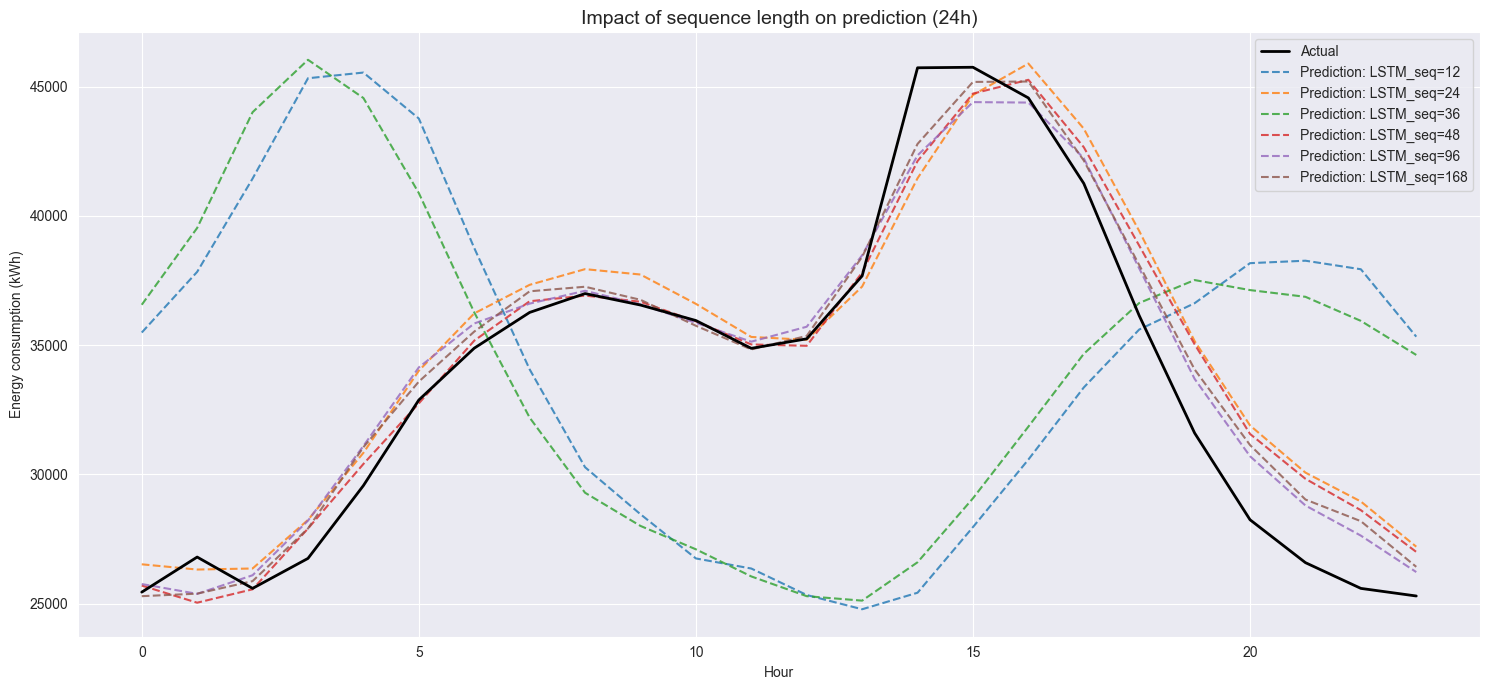

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# test, train, scale
n_train = int(0.8 * len(data_filtered))
train_data_orig = data_filtered.iloc[:n_train]
test_data_orig = data_filtered.iloc[n_train:]

scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data_orig)
test_data_scaled = scaler.transform(test_data_orig)

INPUT_SIZE = len(features)
HORIZON = 24
BATCH_SIZE = 64


def plot_comparison(test_df, predictions_dict, target_col, horizon):
    plt.figure(figsize=(15, 7))
    
    actual = test_df[target_col].values[:horizon]
    plt.plot(actual, label='Actual', color='black', lw=2, zorder=10)
    
    for name, preds in predictions_dict.items():
        plt.plot(preds, label=f'Prediction: {name}', linestyle='--', alpha=0.8)
        
    plt.title(f'Impact of sequence length on prediction ({horizon}h)', fontsize=14)
    plt.xlabel('Hour')
    plt.ylabel('Energy consumption (kWh)')
    plt.legend()
    plt.tight_layout()
    plt.show()

all_preds_to_plot = {}
seq_lengths = [12, 24, 36, 48, 96, 168]

for s_len in seq_lengths:
    exp_name = f'LSTM_seq={s_len}'
    print(f"Training: {exp_name}")
    
    train_ds = MultivariateSeqDataset(train_data_scaled, s_len, HORIZON, target_idx, seq2seq=True)
    test_ds = MultivariateSeqDataset(test_data_scaled, s_len, HORIZON, target_idx, seq2seq=True)
    
    tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    te_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model = LSTMSeq2Seq(input_size=len(features), hidden=64, horizon=HORIZON).to(device)
    trained_model, _, _ = train_lstm(model, tr_loader, te_loader, epochs=15)
    
    model.eval()
    with torch.no_grad():
        x_sample, _ = test_ds[0]
        x_sample = x_sample.unsqueeze(0).to(device)
        pred_scaled = model(x_sample).cpu().numpy().flatten()
        
        dummy = np.zeros((HORIZON, len(features)))
        dummy[:, target_idx] = pred_scaled
        pred_final = scaler.inverse_transform(dummy)[:, target_idx]
        
        all_preds_to_plot[exp_name] = pred_final

test_df_orig = data_filtered.iloc[n_train:]
plot_comparison(test_df_orig, all_preds_to_plot, 'PowerConsumption_Zone1', HORIZON)

## Seq2One


Training for seq_len=12, hidden_units=16
Epoch 5/15 | Train Loss: 0.1030 | Val Loss: 0.0940
Epoch 10/15 | Train Loss: 0.0786 | Val Loss: 0.1158
Epoch 15/15 | Train Loss: 0.0717 | Val Loss: 0.1116

Training for seq_len=12, hidden_units=32
Epoch 5/15 | Train Loss: 0.0859 | Val Loss: 0.1422
Epoch 10/15 | Train Loss: 0.0734 | Val Loss: 0.1311
Epoch 15/15 | Train Loss: 0.0661 | Val Loss: 0.1127

Training for seq_len=12, hidden_units=48
Epoch 5/15 | Train Loss: 0.0828 | Val Loss: 0.1714
Epoch 10/15 | Train Loss: 0.0705 | Val Loss: 0.1427
Epoch 15/15 | Train Loss: 0.0647 | Val Loss: 0.1179

Training for seq_len=12, hidden_units=64
Epoch 5/15 | Train Loss: 0.0851 | Val Loss: 0.1433
Epoch 10/15 | Train Loss: 0.0706 | Val Loss: 0.1178
Epoch 15/15 | Train Loss: 0.0635 | Val Loss: 0.1164

Training for seq_len=24, hidden_units=16
Epoch 5/15 | Train Loss: 0.1120 | Val Loss: 0.1374
Epoch 10/15 | Train Loss: 0.0870 | Val Loss: 0.1392
Epoch 15/15 | Train Loss: 0.0794 | Val Loss: 0.1090

Training for s

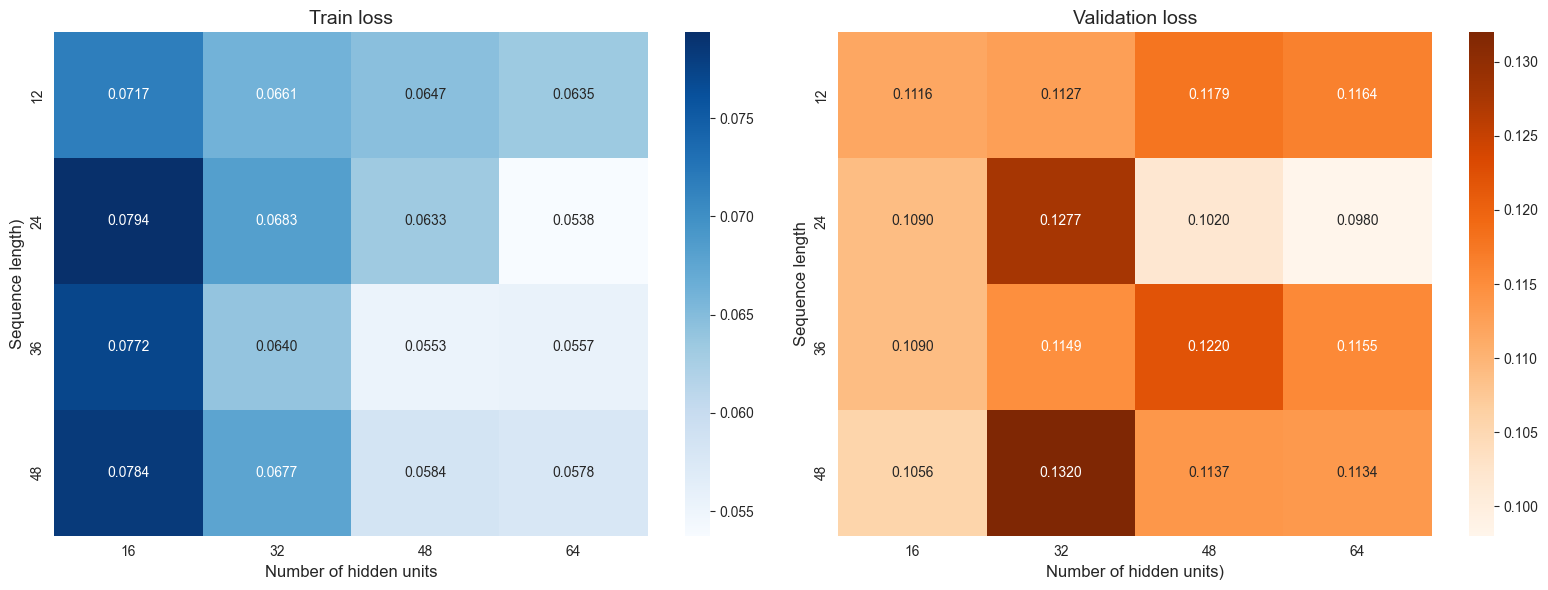

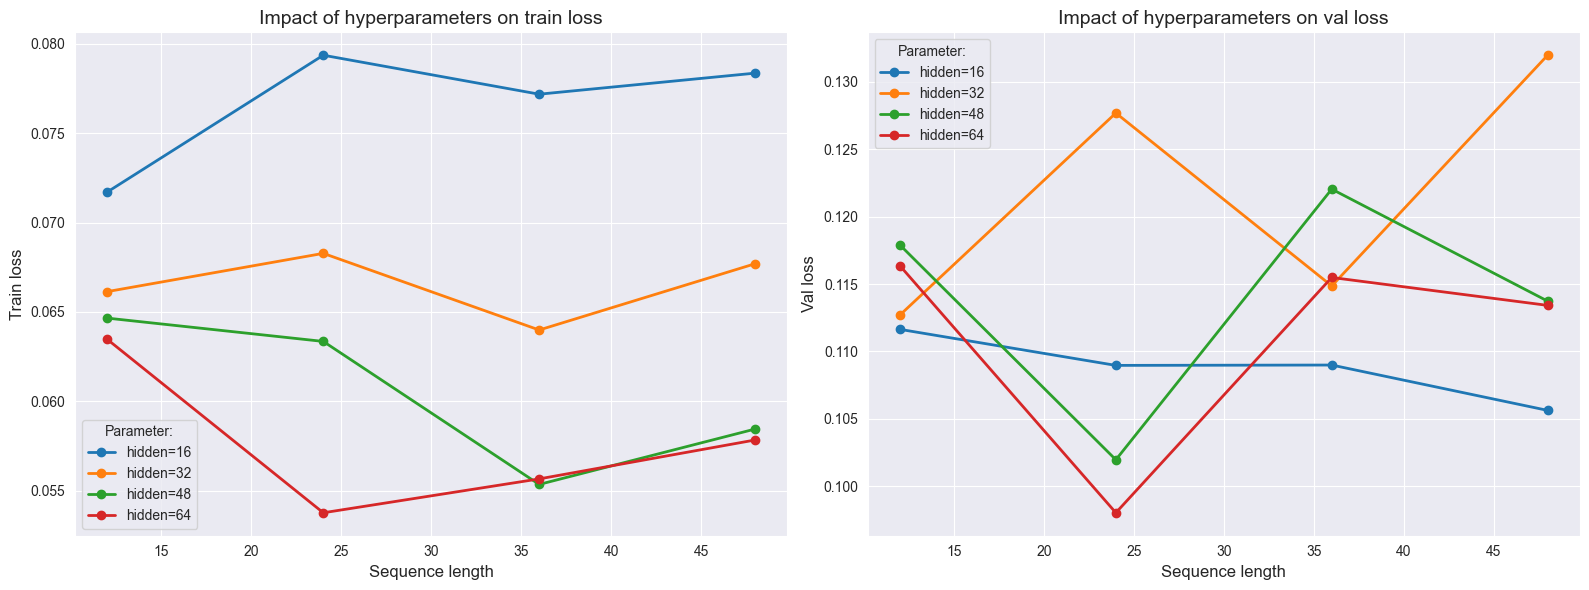

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

seq_lengths = [12, 24, 36, 48]
hidden_sizes = [16, 32, 48, 64]

final_train_losses = np.zeros((len(seq_lengths), len(hidden_sizes)))
final_val_losses = np.zeros((len(seq_lengths), len(hidden_sizes)))

for i, seq in enumerate(seq_lengths):
    for j, hid in enumerate(hidden_sizes):
        print(f"\nTraining for seq_len={seq}, hidden_units={hid}")
        
        train_ds = MultivariateSeqDataset(train_data_scaled, seq, HORIZON, target_idx, seq2seq=False)
        test_ds = MultivariateSeqDataset(test_data_scaled, seq, HORIZON, target_idx, seq2seq=False)
        
        tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
        te_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
        
        model = LSTMSeq2One(input_size=len(features), hidden=hid).to(device)
        
        trained_model, t_loss, v_loss = train_lstm(model, tr_loader, te_loader, epochs=15)
        
        final_train_losses[i, j] = t_loss[-1]
        final_val_losses[i, j] = v_loss[-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(final_train_losses, annot=True, fmt=".4f", 
            xticklabels=hidden_sizes, yticklabels=seq_lengths, cmap="Blues", ax=axes[0])
axes[0].set_title("Train loss", fontsize=14)
axes[0].set_xlabel("Number of hidden units", fontsize=12)
axes[0].set_ylabel("Sequence length)", fontsize=12)

sns.heatmap(final_val_losses, annot=True, fmt=".4f", 
            xticklabels=hidden_sizes, yticklabels=seq_lengths, cmap="Oranges", ax=axes[1])
axes[1].set_title("Validation loss", fontsize=14)
axes[1].set_xlabel("Number of hidden units)", fontsize=12)
axes[1].set_ylabel("Sequence length", fontsize=12)

plt.tight_layout()
plt.show()

# --- WIZUALIZACJA 2: WYKRESY LINIOWE ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for j, hid in enumerate(hidden_sizes):
    axes[0].plot(seq_lengths, final_train_losses[:, j], marker='o', lw=2, label=f'hidden={hid}')
    axes[1].plot(seq_lengths, final_val_losses[:, j], marker='o', lw=2, label=f'hidden={hid}')

axes[0].set_title("Impact of hyperparameters on train loss", fontsize=14)
axes[0].set_xlabel("Sequence length", fontsize=12)
axes[0].set_ylabel("Train loss", fontsize=12)
axes[0].legend(title="Parameter:")

axes[1].set_title("Impact of hyperparameters on val loss", fontsize=14)
axes[1].set_xlabel("Sequence length", fontsize=12)
axes[1].set_ylabel("Val loss", fontsize=12)
axes[1].legend(title="Parameter:")

plt.tight_layout()
plt.show()

## LSTM vs Prophet vs ARIMA

p-value: 0.0000


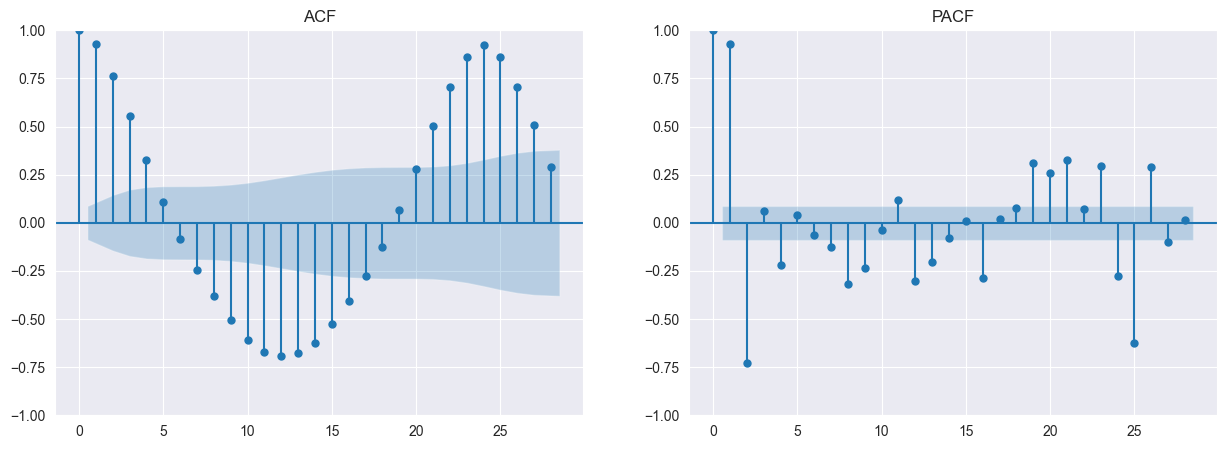

23:38:00 - cmdstanpy - INFO - Chain [1] start processing
23:38:08 - cmdstanpy - INFO - Chain [1] done processing



--- Trenowanie LSTM ---
Epoch 5/15 | Train Loss: 0.0930 | Val Loss: 0.0587
Epoch 10/15 | Train Loss: 0.0762 | Val Loss: 0.0541
Epoch 15/15 | Train Loss: 0.0604 | Val Loss: 0.0427
ARIMA          : 5175.77
Prophet        : 1636.18
LSTM           : 1526.42


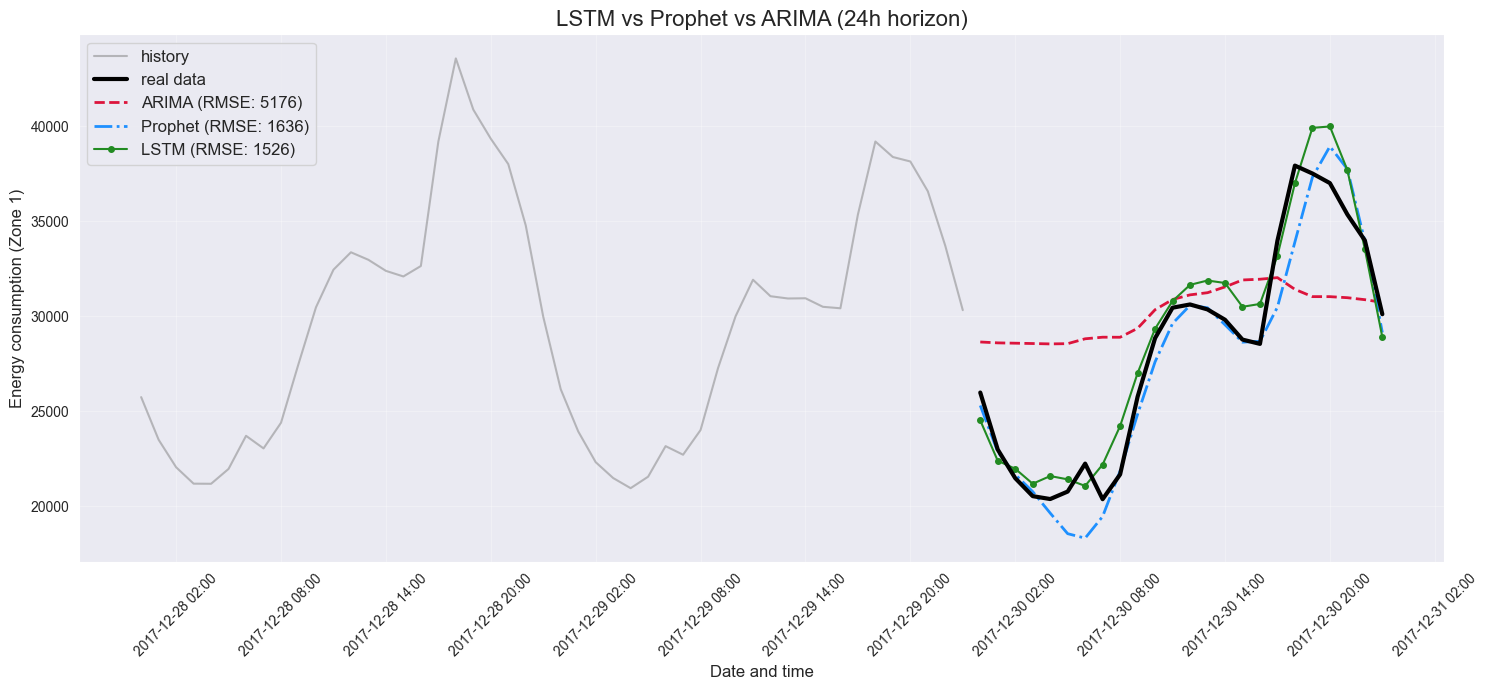

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# 1 DATA
HORIZON = 24
target_col = 'PowerConsumption_Zone1'
exog_cols = ['Temperature', 'Humidity', 'WindSpeed', 'hour', 'dayofweek']

train_orig = data_filtered.iloc[:-HORIZON].copy()
test_orig = data_filtered.iloc[-HORIZON:].copy()

results_rmse = {}
model_predictions = {}

# 2 ARIMA

recent_train_orig = train_orig.iloc[-504:]
target_series = recent_train_orig[target_col]

adf_result = adfuller(target_series)
print(f"p-value: {adf_result[1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(target_series, ax=ax1, title="ACF")
plot_pacf(target_series, ax=ax2, title="PACF")
plt.show()

arima_exog_cols = ['Temperature', 'Humidity', 'WindSpeed']

arima_model = ARIMA(endog=target_series,
                    exog=recent_train_orig[arima_exog_cols],
                    order=(1, 0, 1),
                    enforce_stationarity=False,
                    enforce_invertibility=False)

arima_fit = arima_model.fit()

# forecast
forecast_obj = arima_fit.get_forecast(steps=HORIZON, exog=test_orig[arima_exog_cols])
model_predictions['ARIMA'] = forecast_obj.predicted_mean.values
results_rmse['ARIMA'] = np.sqrt(mean_squared_error(test_orig[target_col], model_predictions['ARIMA']))

# 3 Prophet

prophet_df = train_orig.reset_index().rename(columns={'Datetime': 'ds', target_col: 'y'})

model_prophet = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
for col in exog_cols:
    model_prophet.add_regressor(col)

model_prophet.fit(prophet_df)

future_df = test_orig.reset_index().rename(columns={'Datetime': 'ds'})
prophet_preds_full = model_prophet.predict(future_df)
model_predictions['Prophet'] = prophet_preds_full['yhat'].values
results_rmse['Prophet'] = np.sqrt(mean_squared_error(test_orig[target_col], model_predictions['Prophet']))


# 4 LSTM
SEQ_LEN = 24
HIDDEN_UNITS = 32

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_orig)

split_idx = int(0.9 * len(train_scaled))
lstm_train_data = train_scaled[:split_idx]
lstm_val_data = train_scaled[split_idx:]

train_ds = MultivariateSeqDataset(lstm_train_data, SEQ_LEN, HORIZON, target_idx, seq2seq=True)
val_ds = MultivariateSeqDataset(lstm_val_data, SEQ_LEN, HORIZON, target_idx, seq2seq=True)

tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

model_lstm = LSTMSeq2Seq(input_size=len(features), hidden=HIDDEN_UNITS, horizon=HORIZON).to(device)

trained_model, _, _ = train_lstm(model_lstm, tr_loader, val_loader, epochs=15)

model_lstm.eval()
with torch.no_grad():
    x_input = torch.FloatTensor(train_scaled[-SEQ_LEN:]).unsqueeze(0).to(device)
    pred_scaled = model_lstm(x_input).cpu().numpy().flatten()
    
    dummy = np.zeros((HORIZON, len(features)))
    dummy[:, target_idx] = pred_scaled
    pred_final = scaler.inverse_transform(dummy)[:, target_idx]
    
model_predictions['LSTM'] = pred_final
results_rmse['LSTM'] = np.sqrt(mean_squared_error(test_orig[target_col], model_predictions['LSTM']))


# Visualization
for name, error in results_rmse.items():
    print(f"{name: <15}: {error:.2f}")

plt.figure(figsize=(15, 7))
plt.plot(train_orig.index[-48:], train_orig[target_col].iloc[-48:], color='grey', label='history', alpha=0.5)

plt.plot(test_orig.index, test_orig[target_col], label='real data', color='black', lw=3, zorder=10)

plt.plot(test_orig.index, model_predictions['ARIMA'], label=f"ARIMA (RMSE: {results_rmse['ARIMA']:.0f})", color='crimson', ls='--', lw=2)
plt.plot(test_orig.index, model_predictions['Prophet'], label=f"Prophet (RMSE: {results_rmse['Prophet']:.0f})", color='dodgerblue', ls='-.', lw=2)
plt.plot(test_orig.index, model_predictions['LSTM'], label=f"LSTM (RMSE: {results_rmse['LSTM']:.0f})", color='forestgreen', ls='-', marker='o', markersize=4)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.xticks(rotation=45)

plt.title('LSTM vs Prophet vs ARIMA (24h horizon)', fontsize=16)
plt.xlabel('Date and time', fontsize=12)
plt.ylabel('Energy consumption (Zone 1)', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4.2

In [11]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np


SEQ_LEN_ATTN = 48
HIDDEN_UNITS_ATTN = 64

train_ds_attn = MultivariateSeqDataset(train_data_scaled, SEQ_LEN_ATTN, HORIZON, target_idx, seq2seq=True)
test_ds_attn = MultivariateSeqDataset(test_data_scaled, SEQ_LEN_ATTN, HORIZON, target_idx, seq2seq=True)
tr_loader_attn = DataLoader(train_ds_attn, batch_size=BATCH_SIZE, shuffle=True)
te_loader_attn = DataLoader(test_ds_attn, batch_size=BATCH_SIZE, shuffle=False)

class LSTMAttentionModel(nn.Module):
    def __init__(self, input_size=len(features), hidden=64, layers=2, dropout=0.2, n_heads=4, horizon=HORIZON):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers, 
                            dropout=dropout if layers>1 else 0, 
                            batch_first=True)
        
        # nn.MultiheadAttention: Q=K=V=lstm_output (self-attention)
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden, 
            num_heads=n_heads, 
            dropout=dropout, 
            batch_first=True
        )
        
        self.norm = nn.LayerNorm(hidden)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), 
            nn.GELU(), 
            nn.Linear(32, horizon)
        )
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # (Batch, T, hidden)
        
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out) 
        
        out = self.norm(lstm_out + attn_out) # residual + LN
        pooled = self.dropout(out.mean(dim=1)) # global avg pool
        
        return self.head(pooled)

model_attn = LSTMAttentionModel(input_size=len(features), hidden=HIDDEN_UNITS_ATTN, horizon=HORIZON).to(device)

print(f"LSTM+Attention: {sum(p.numel() for p in model_attn.parameters()):,}")

trained_attn, tr_loss_attn, val_loss_attn = train_lstm(model_attn, tr_loader_attn, te_loader_attn, epochs=15)

model_attn.eval()
with torch.no_grad():
    x_input = torch.FloatTensor(train_scaled[-SEQ_LEN_ATTN:]).unsqueeze(0).to(device)
    pred_scaled = model_attn(x_input).cpu().numpy().flatten()
    
    dummy = np.zeros((HORIZON, len(features)))
    dummy[:, target_idx] = pred_scaled
    pred_final_attn = scaler.inverse_transform(dummy)[:, target_idx]

rmse_attn = np.sqrt(mean_squared_error(test_orig[target_col], pred_final_attn))
print(f"RMSE for LSTM+Attention: {rmse_attn:.2f}")

LSTM+Attention: 71,352
Epoch 5/15 | Train Loss: 0.1483 | Val Loss: 0.1789
Epoch 10/15 | Train Loss: 0.1102 | Val Loss: 0.1041
Epoch 15/15 | Train Loss: 0.0936 | Val Loss: 0.0939
RMSE for LSTM+Attention: 2798.10


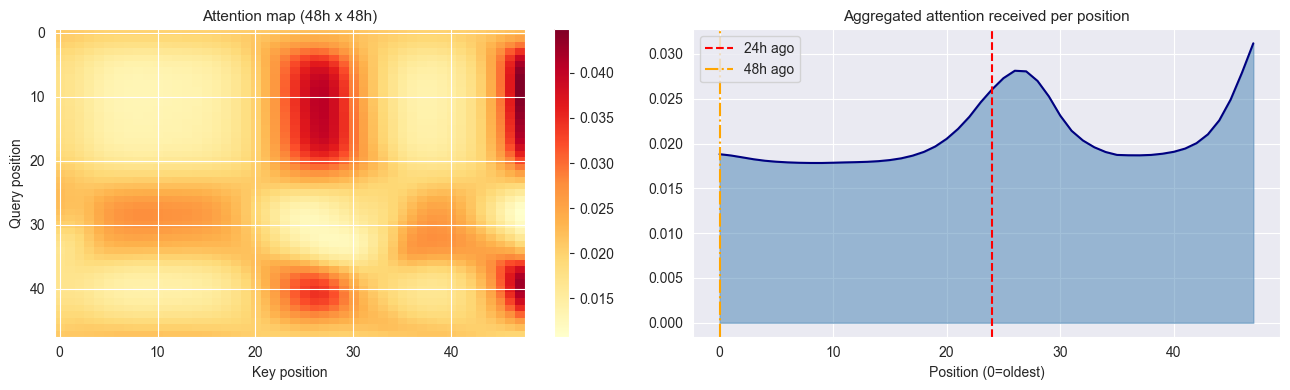

In [12]:
model_attn.eval()

sample_x, _ = train_ds_attn[0] 
sx = sample_x.unsqueeze(0).to(device)

with torch.no_grad():
    lo, _ = model_attn.lstm(sx)
    attn_out, w = model_attn.attn(lo, lo, lo) 
    
    avg_w = w[0].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = axes[0].imshow(avg_w, aspect='auto', cmap='YlOrRd')
axes[0].set_title(f'Attention map ({SEQ_LEN_ATTN}h x {SEQ_LEN_ATTN}h)', fontsize=11)
axes[0].set_xlabel('Key position')
axes[0].set_ylabel('Query position')
plt.colorbar(im, ax=axes[0])

# Aggregated attention received per position
received = avg_w.mean(axis=0)
axes[1].fill_between(range(SEQ_LEN_ATTN), received, alpha=0.5, color='steelblue')
axes[1].plot(received, color='navy')
axes[1].axvline(SEQ_LEN_ATTN-24, color='red', ls='--', label='24h ago')

if SEQ_LEN_ATTN >= 48:
    axes[1].axvline(SEQ_LEN_ATTN-48, color='orange', ls='-.', label='48h ago')g

axes[1].set_title('Aggregated attention received per position', fontsize=11)
axes[1].set_xlabel('Position (0=oldest)')
axes[1].legend()

plt.tight_layout()
plt.show()